In [220]:
words = open('names.txt', 'r', encoding="utf-8").read().splitlines()

In [221]:
import re
cleaned_words = []
for w in words:
    w = w.strip().lower()
    w = re.sub(r'[^a-z]', '', w)
    if w:
        cleaned_words.append(w)
chars = sorted(list(set(''.join(cleaned_words))))
print(f"Unique characters: {len(chars)}")  # Should be close to 26

Unique characters: 26


In [222]:
min(len(w) for w in cleaned_words)

1

In [223]:
max(len(w) for w in cleaned_words)

27

In [224]:
b = {}
for w in cleaned_words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

In [6]:
# sorted(b.items(), key=lambda kv: -kv[1])

# Output:
# [(('e', '<E>'), 825),
#  (('s', '<E>'), 689),
#  (('e', 'r'), 674),
#  (('<S>', 's'), 652),
#  (('i', 'n'), 613),
#  (('a', 'r'), 551),
#  (('a', '<E>'), 499),
#  (('r', 'e'), 487),
#  (('<S>', 'c'), 475),
#  (('a', 'n'), 471),

In [225]:
import torch

In [226]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [227]:
chars = sorted(list(set(''.join(cleaned_words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [228]:
# stoi

In [229]:
for w in cleaned_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

In [230]:
import matplotlib.pyplot as plt
%matplotlib inline

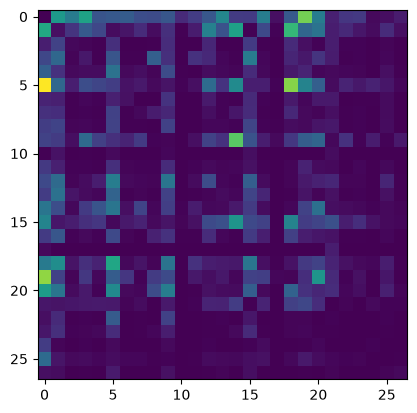

In [231]:
plt.imshow(N)

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

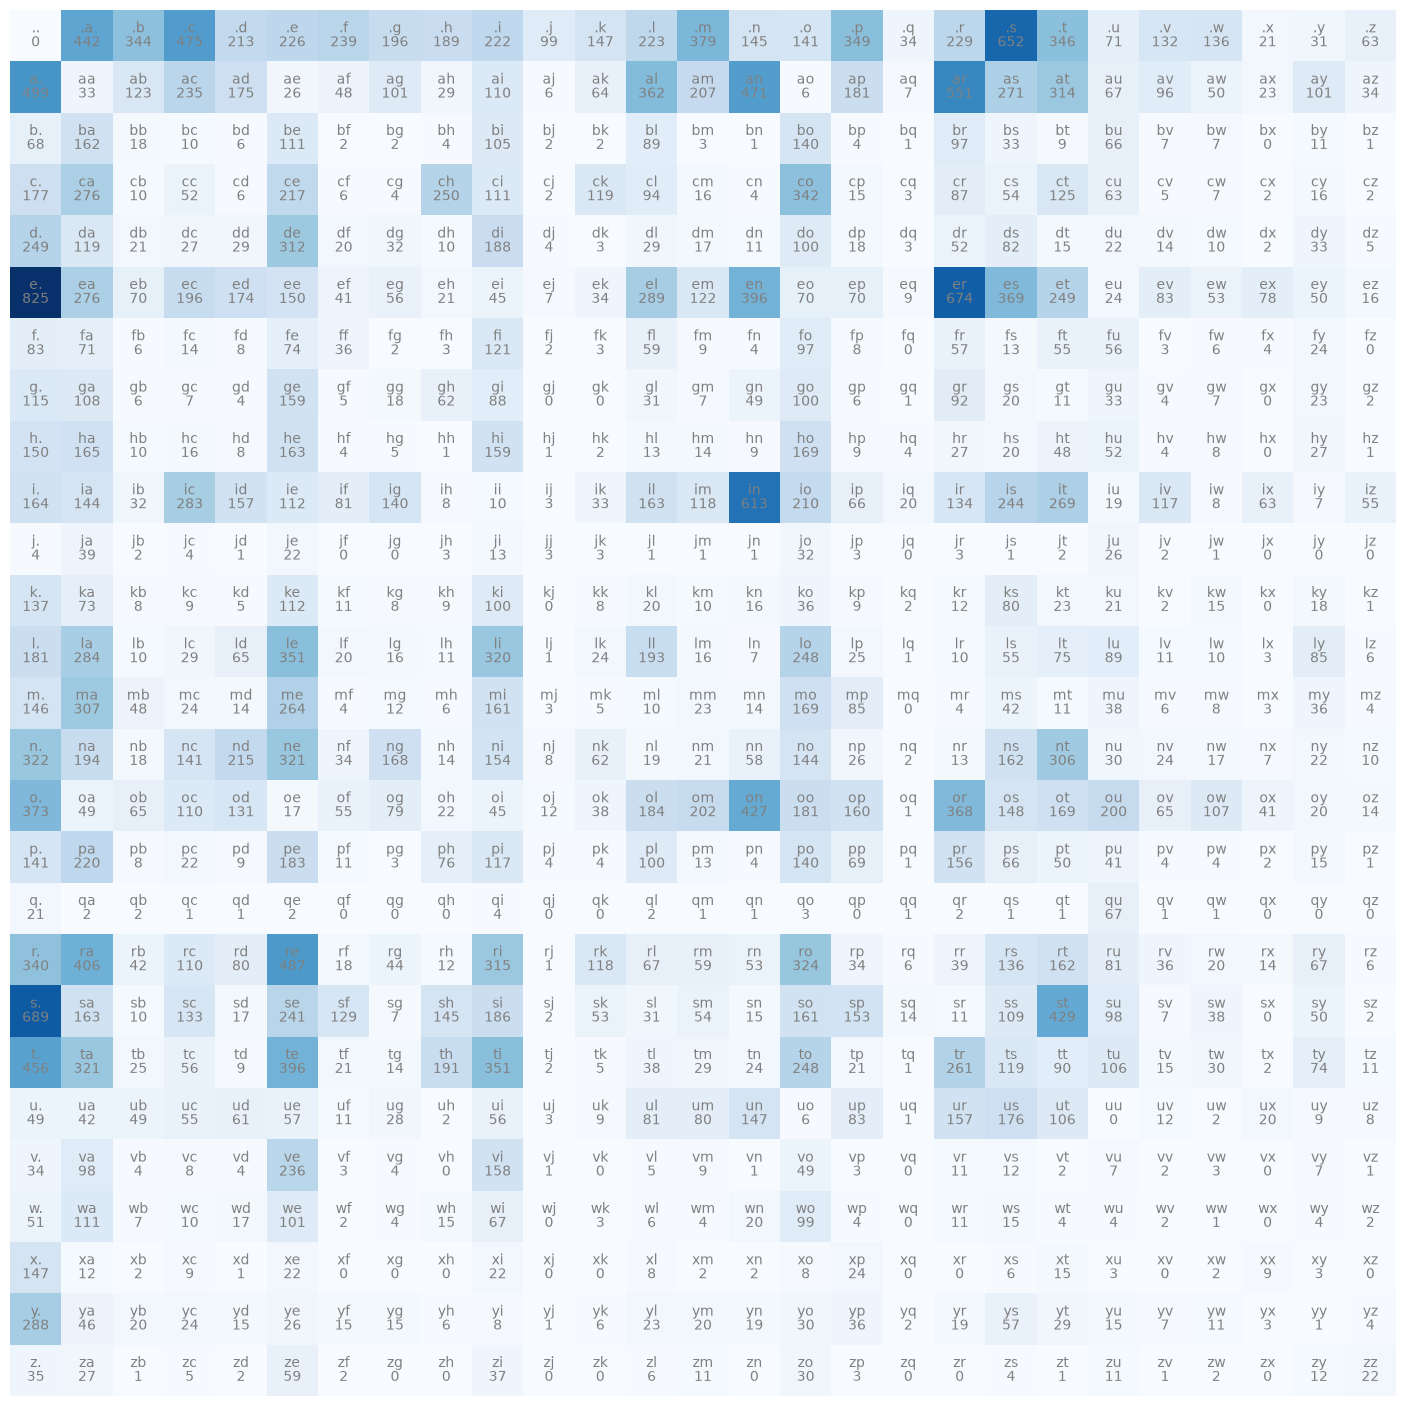

In [232]:
plt.figure(figsize = (18, 18))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")

plt.axis('off')

In [233]:
N[0]

tensor([  0, 442, 344, 475, 213, 226, 239, 196, 189, 222,  99, 147, 223, 379,
        145, 141, 349,  34, 229, 652, 346,  71, 132, 136,  21,  31,  63],
       dtype=torch.int32)

In [234]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.0769, 0.0599, 0.0827, 0.0371, 0.0393, 0.0416, 0.0341, 0.0329,
        0.0386, 0.0172, 0.0256, 0.0388, 0.0660, 0.0252, 0.0245, 0.0608, 0.0059,
        0.0399, 0.1135, 0.0602, 0.0124, 0.0230, 0.0237, 0.0037, 0.0054, 0.0110])

In [235]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [236]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)


In [237]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    ix = 0
    out = []
    while True:
        # p = N[ix].float()
        # p = p/p.sum()
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))

cex.
malogllurkicazityharellimittainelksun.
ka.
da.
startpubltrsc.
gotas.
icliseltio.
sfotedogealerkamsede.
enkavernghftbsp.
hicivenvtarevec.


In [238]:
log_likelihood = 0.0
n = 0
for w in cleaned_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        n+= 1
        # print(f"{ch1}{ch2}-> {prob:.4f} | {log_prob:.4f}")
print("Log Likelihood: ", log_likelihood.item())
nll = -log_likelihood
print(f"Negative Log Likelihood: {nll}")
print(f"Normalized NLL: {nll/n}")

Log Likelihood:  -134248.859375
Negative Log Likelihood: 134248.859375
Normalized NLL: 2.70444917678833


In [239]:
import torch.nn.functional as F


In [240]:
# create training set of all bigrams
xs, ys = [], []

for w in cleaned_words:
    w = w.lower()
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs = torch.tensor(xs)  
ys = torch.tensor(ys)
num = xs.nelement()
print('Number of examples: ', num)
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad = True)

Number of examples:  49640


In [ ]:
for k in range(1000):
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    prob = counts / counts.sum(1, keepdims=True)
    loss = -prob[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()
    print("Loss: ", loss.item())
    W.grad = None
    loss.backward()

    W.data += -100 * W.grad

# Outputs:
# Loss:  2.7217659950256348
# Loss:  2.7217657566070557
# Loss:  2.7217659950256348
# Loss:  2.7217657566070557
# Loss:  2.7217657566070557

In [242]:
# Results 
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    ix = 0
    out = []
    while True:
        xenc = F.one_hot(xs, num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        P = counts / counts.sum(1, keepdims=True)
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print("".join(out))

cexbr.
cogpsuraic.
zktytnml.
zimitnainrlksdk.
ka.
da.
sncxtpubltrhr.
gotos.
ic.
isl.
